In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [2]:
d = 8
splitting = 1
freqs = np.arange(-(d/2-1)*splitting, (d/2-1)*splitting + 1e-9, splitting)

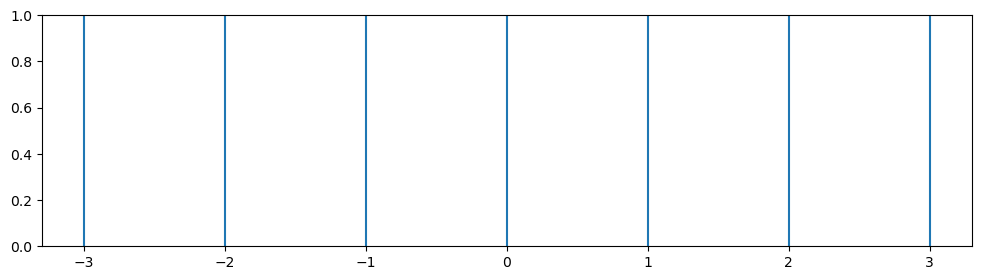

In [3]:
f = plt.figure(figsize=(12,3))
for i in range(d-1):
    plt.axvline(freqs[i])

In [159]:
def Hrf_det(det, splitting=1):
    Hrf = splitting/2*qt.jmat((d-1)/2, 'z')**2 - 0.125*qt.identity(8)
    return Hrf - det*qt.jmat((d-1)/2, 'z')

In [160]:
Hrf_det(0)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[6. 0. 0. 0. 0. 0. 0. 0.]
 [0. 3. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 0. 0. 0. 6.]]

In [161]:
Hrf_det(1)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 2.5  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.5  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.5  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   2.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   5.5  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   9.5]]

In [162]:
Hrf_drive = qt.jmat((d-1)/2, 'x')
Hrf_drive

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.         1.32287566 0.         0.         0.         0.
  0.         0.        ]
 [1.32287566 0.         1.73205081 0.         0.         0.
  0.         0.        ]
 [0.         1.73205081 0.         1.93649167 0.         0.
  0.         0.        ]
 [0.         0.         1.93649167 0.         2.         0.
  0.         0.        ]
 [0.         0.         0.         2.         0.         1.93649167
  0.         0.        ]
 [0.         0.         0.         0.         1.93649167 0.
  1.73205081 0.        ]
 [0.         0.         0.         0.         0.         1.73205081
  0.         1.32287566]
 [0.         0.         0.         0.         0.         0.
  1.32287566 0.        ]]

In [163]:
def Hfull(det, drive, splitting=1):
    return Hrf_det(det, splitting) + Hrf_drive*drive

In [164]:
Hfull(1, 1)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 2.5         1.32287566  0.          0.          0.          0.
   0.          0.        ]
 [ 1.32287566  0.5         1.73205081  0.          0.          0.
   0.          0.        ]
 [ 0.          1.73205081 -0.5         1.93649167  0.          0.
   0.          0.        ]
 [ 0.          0.          1.93649167 -0.5         2.          0.
   0.          0.        ]
 [ 0.          0.          0.          2.          0.5         1.93649167
   0.          0.        ]
 [ 0.          0.          0.          0.          1.93649167  2.5
   1.73205081  0.        ]
 [ 0.          0.          0.          0.          0.          1.73205081
   5.5         1.32287566]
 [ 0.          0.          0.          0.          0.          0.
   1.32287566  9.5       ]]

In [68]:
time = np.linspace(0, 100, 100)
pops = []
init_state = qt.basis(d, 0)
for t in time:
    U = (-1j*2*np.pi*Hfull(3.03*splitting, 0.01)*t).expm()
    pops.append(np.diag(np.real(qt.ket2dm(U @ init_state).full())))

pops = np.array(pops)


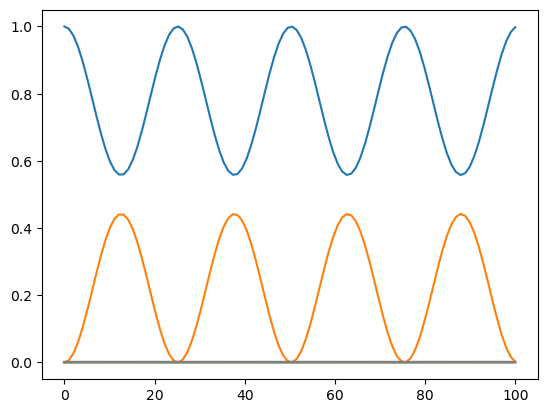

In [69]:
plt.plot(time, pops)


In [159]:
700/25e3

0.028

In [236]:
time = np.linspace(0, 100, 1000)
pops = []
phases = []
init_state = 1/np.sqrt(d) * np.sum(qt.basis(d, i) for i in range(d))

detuning = 3*splitting
drive = 0.03
for t in time:
    U = (-1j*2*np.pi*Hfull(detuning, drive)*t).expm()
    pops.append(np.diag(np.real(qt.ket2dm(U @ init_state).full())))
    
    rf_change = (-1j*2*np.pi*detuning*qt.jmat((d-1)/2, 'z')*t).expm() # go back to origanl rotating frame
    rf_change = (1j*2*np.pi*Hrf*t).expm() * rf_change # to generalised rotating frame (no quadratic term)

    phases.append(np.angle(np.diag(qt.ket2dm(rf_change * U * init_state).full(),1)))

    

pops = np.array(pops)
phases = np.array(phases)

C:\Users\z5459883\AppData\Local\Temp\ipykernel_9620\1502224565.py:4: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  init_state = 1/np.sqrt(d) * np.sum(qt.basis(d, i) for i in range(d))


In [237]:
for i in range(phases.shape[0]):
    for j in range(phases.shape[1]):
        if phases[i, j] - phases[i-1, j] > np.pi:
            phases[i:, j] -= 2*np.pi
        elif phases[i, j] - phases[i-1, j] < -np.pi:
            phases[i:, j] += 2*np.pi


(-3.141592653589793, 3.141592653589793)

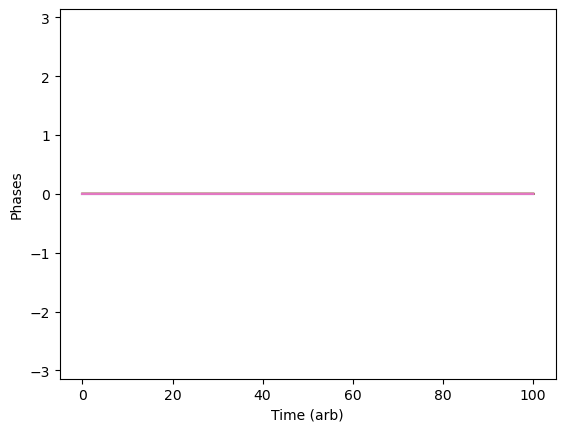

In [238]:
plt.plot(time, phases)
plt.ylabel('Phases')
plt.xlabel('Time (arb)')
plt.ylim(-np.pi, np.pi)

In [295]:
stark_shifts = np.polyfit(time, phases, 1)[0, :]

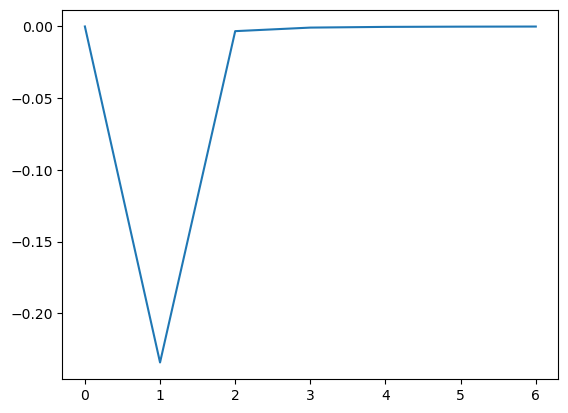

In [296]:
plt.plot(stark_shifts)

In [22]:
1/0.03

33.333333333333336

In [345]:
def calculate_stark_shift(f, splitting=1, drive=0.03, Nt=30, nT=10, plot=False):
    time = np.linspace(0, nT/drive, Nt)
    pops = []
    phases = []
    init_state = 1/np.sqrt(d) * np.sum(qt.basis(d, i) for i in range(d))

    Hrf = splitting/2*qt.jmat((d-1)/2, 'z')**2 - 0.125*qt.identity(8)

    for t in time:
        U = (-1j*2*np.pi*Hfull(f, drive, splitting)*t).expm()

        pops.append(np.diag(np.real(qt.ket2dm(U @ init_state).full())))
        
        rf_change = (-1j*2*np.pi*f*qt.jmat((d-1)/2, 'z')*t).expm() # go back to origanl rotating frame
        rf_change = (1j*2*np.pi*Hrf*t).expm() * rf_change # to generalised rotating frame (no quadratic term)

        phases.append(np.angle(np.diag(qt.ket2dm(rf_change * U * init_state).full(),1)))

    pops = np.array(pops)
    phases = np.array(phases)
    
    for i in range(1, phases.shape[0]):
        for j in range(pops.shape[1]):
            if pops[i, j] < 0.001:
                if j < pops.shape[1]-1:
                    phases[i, j] = np.nan
                if j > 0:
                    phases[i, j-1] = np.nan

            if j < phases.shape[1]:
                if np.abs((phases[i, j] - phases[i-1, j]) - 2*np.pi) < 0.05:
                    phases[i:, j] -= 2*np.pi
                elif np.abs((phases[i, j] - phases[i-1, j]) + 2*np.pi) < 0.05:
                    phases[i:, j] += 2*np.pi

            #     if np.abs((phases[i, j] - phases[i-1, j]) - np.pi) < 0.05:
            #         phases[i:, j] -= np.pi
            #     elif np.abs((phases[i, j] - phases[i-1, j]) + np.pi) < 0.05:
            #         phases[i:, j] += np.pi
            
    diff =  np.diff(phases, axis=0)
    diff[np.where(diff > np.pi)] -= 2*np.pi
    diff[np.where(diff < -np.pi)] += 2*np.pi
    dt = time[1] - time[0]
    stark_shifts = np.nanmean(diff, axis=0)/dt

    if plot:
        plt.plot(time, pops)
        plt.figure()
        plt.plot(time, phases)
        plt.figure()
        diff =  np.diff(phases, axis=0)
        diff[np.where(diff > np.pi)] -= 2*np.pi
        diff[np.where(diff < -np.pi)] += 2*np.pi
        dt = time[1] - time[0]
        stark_shifts = np.mean(diff, axis=0)/dt
        plt.plot(time[1:], diff/dt)
        plt.figure()
        stark_shifts2 = np.polyfit(time, phases, 1)[0, :]
        plt.plot(stark_shifts)
        plt.plot(stark_shifts2)

    return stark_shifts

C:\Users\z5459883\AppData\Local\Temp\ipykernel_9620\3795316549.py:5: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  init_state = 1/np.sqrt(d) * np.sum(qt.basis(d, i) for i in range(d))


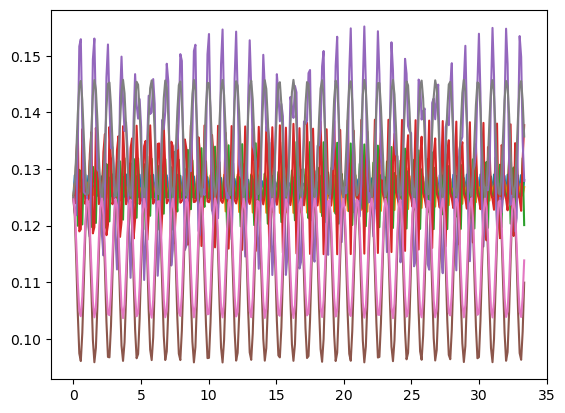

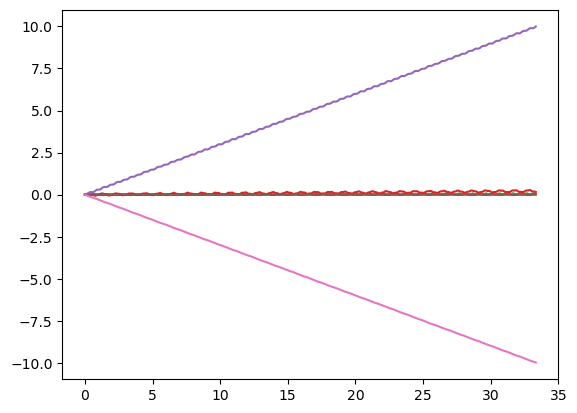

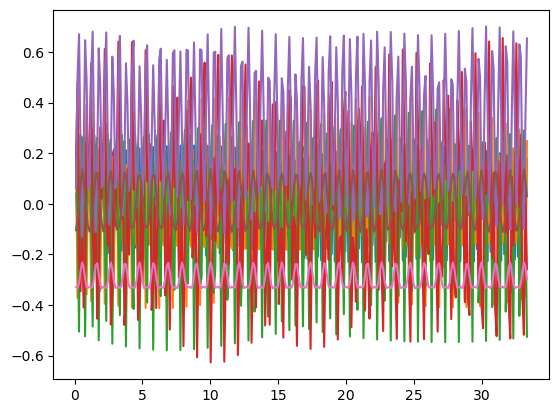

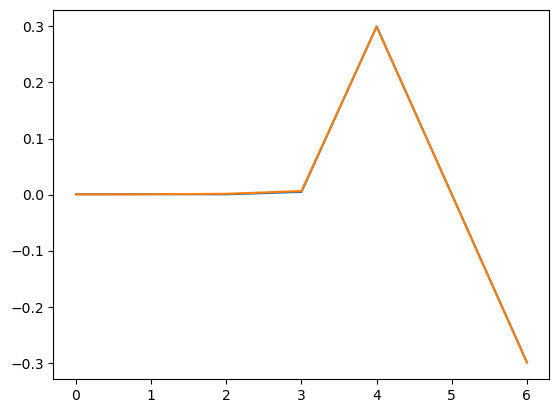

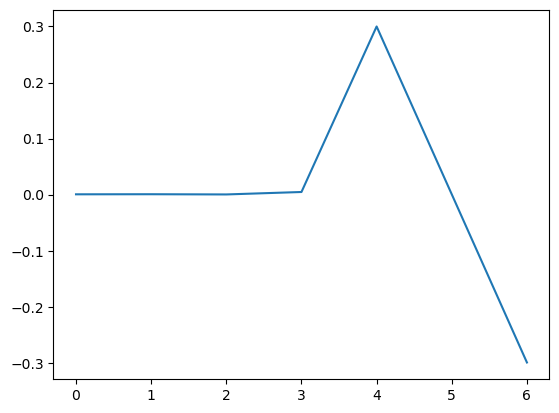

In [346]:
res = calculate_stark_shift(-2, 1, 0.03, nT = 1, Nt=300, plot=True)
plt.figure()
plt.plot(res)

In [120]:
freq_array = np.arange(-7*splitting, 7*splitting+1e-10, 0.01, )

In [265]:

ss_array = np.zeros((len(freq_array), d-1))
for i, f in enumerate(freq_array):
    ss_array[i, :] = calculate_stark_shift(f, drive=0.03, Nt=300, nT=10)

C:\Users\z5459883\AppData\Local\Temp\ipykernel_9620\847095559.py:5: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  init_state = 1/np.sqrt(d) * np.sum(qt.basis(d, i) for i in range(d))


KeyboardInterrupt: 

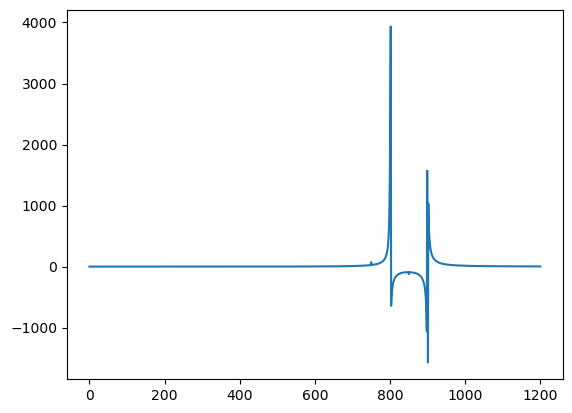

In [ ]:
plt.plot(ss_array[:,0])

In [363]:
ix = np.abs(np.diag(qt.jmat(7/2,'x').full(), 1))

(-0.2, 0.2)

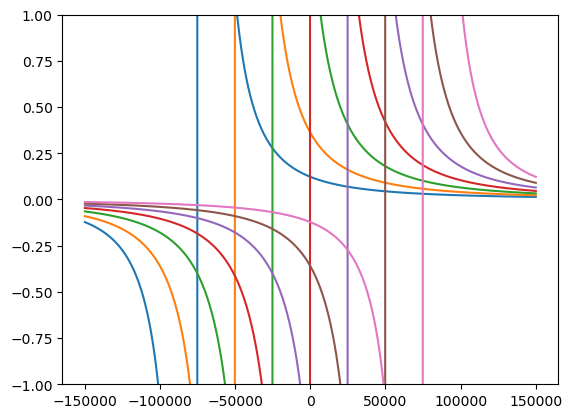

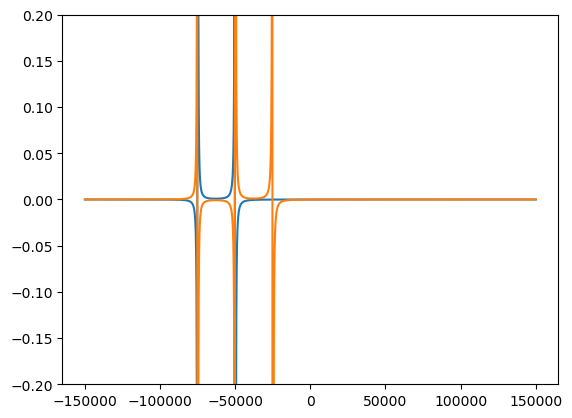

In [372]:
amp = 1/6e-3
geom_phases = np.zeros((7, freq_array.size))
for i, f in enumerate(np.arange(-3, 4)*splitting):
    rabi_F = np.sqrt(amp**2+detuning**2)
    geom_phase = np.pi*(1-np.cos(np.pi/2 - np.arctan((freq_array-f)/amp)))
    geom_phase = np.where(geom_phase > np.pi, geom_phase - 2*np.pi, geom_phase)
    geom_phase*= ix[i]
    geom_phases[i] = geom_phase
    plt.plot(freq_array, geom_phase*rabi_F/2/np.pi)
    plt.ylim(-1, 1)

plt.figure()
plt.plot(freq_array, geom_phases[0] - geom_phases[1])
plt.plot(freq_array, geom_phases[1] - geom_phases[0] - geom_phases[2])
plt.ylim(-0.2, 0.2)

Text(0.5, 0, 'Drive Detuning (arb)')

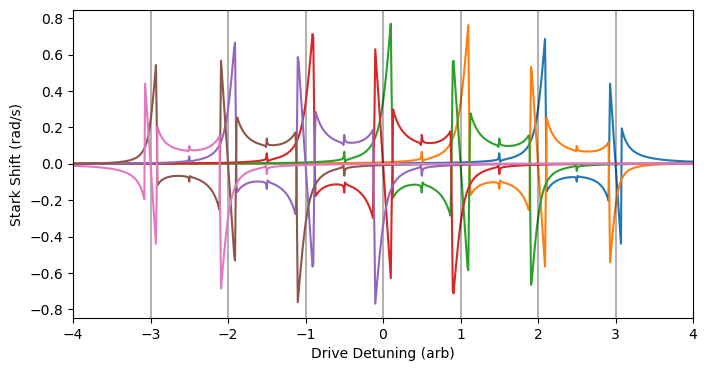

In [134]:
plt.figure(figsize=(8,4))

for i in range(d-1):
    plt.plot(freq_array, ss_array[:, i]+i*0*np.mean(np.max(np.abs(ss_array), 0)))
    plt.axvline(freqs[i], color='k', alpha=0.3)
plt.xlim(-4, 4)
plt.ylabel('Stark Shift (rad/s)')
plt.xlabel('Drive Detuning (arb)')

Text(0.5, 0, 'Drive Detuning (arb)')

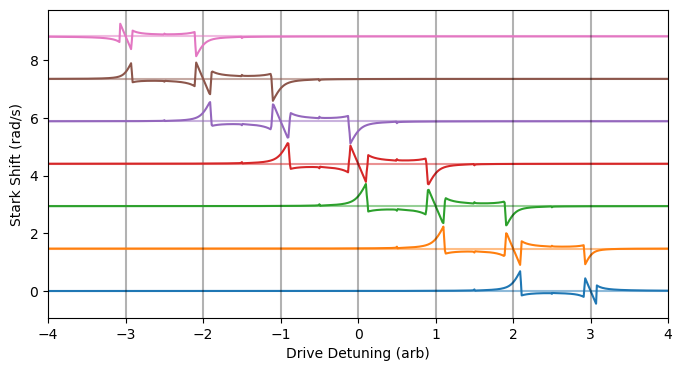

In [133]:
plt.figure(figsize=(8,4))
for i in range(d-1):
    p = plt.plot(freq_array, ss_array[:, i]+i*2*np.mean(np.max(np.abs(ss_array), 0)))
    c = p[0].get_color()
    plt.axhline(i*2*np.mean(np.max(np.abs(ss_array), 0)), color=c, alpha=0.5)
    plt.axvline(freqs[i], color='k', alpha=0.3)
plt.xlim(-4, 4)
plt.ylabel('Stark Shift (rad/s)')
plt.xlabel('Drive Detuning (arb)')

Text(0.5, 0, 'Drive Detuning (arb)')

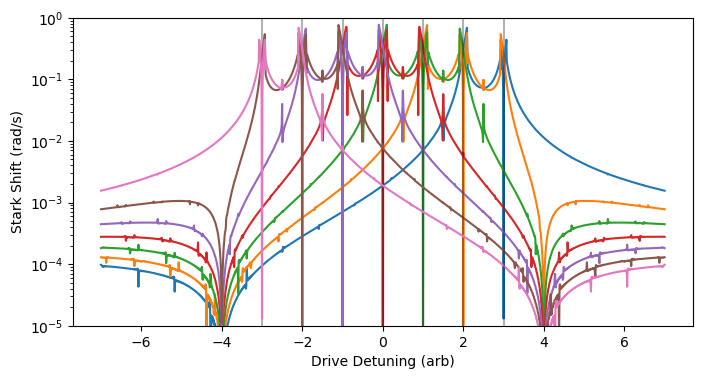

In [141]:
plt.figure(figsize=(8,4))
for i in range(d-1):
    plt.semilogy(freq_array, np.abs(ss_array[:, i]+i*0*np.mean(np.max(np.abs(ss_array), 0))), label=f"State {i}")
    plt.axvline(freqs[i], color='k', alpha=0.3)
# plt.xlim(-4, 4)
plt.ylim(1e-5, 1)
plt.ylabel('Stark Shift (rad/s)')
plt.xlabel('Drive Detuning (arb)')

Text(0.5, 0, 'Transition')

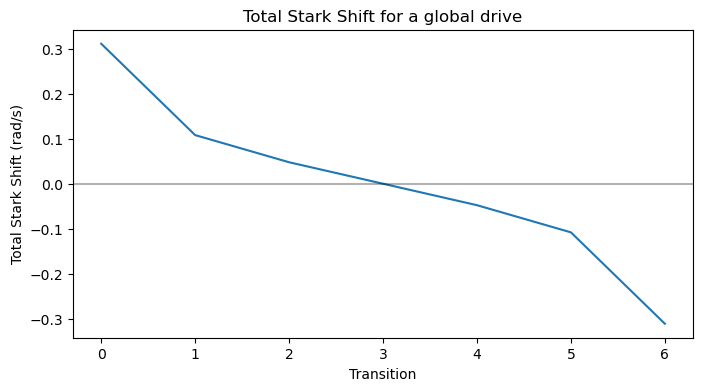

In [144]:
plt.figure(figsize=(8,4))
ifreqs = []
for i in range(d-1):
    ifreqs.append(np.argmin(np.abs(freq_array - freqs[i])))
tot_stark_shift = []
for i in range(d-1):
    tot_stark_shift.append(np.sum(ss_array[ifreqs, i]))
plt.plot(tot_stark_shift)
plt.title('Total Stark Shift for a global drive')
plt.axhline(0, color='k', alpha=0.3)
plt.ylabel('Total Stark Shift (rad/s)')
plt.xlabel('Transition')

In [93]:
ifreqs

[np.int64(100),
 np.int64(200),
 np.int64(300),
 np.int64(400),
 np.int64(500),
 np.int64(600),
 np.int64(700)]

In [94]:
freq_array[ifreqs[0]] -freqs

array([-2.13162821e-14, -1.00000000e+00, -2.00000000e+00, -3.00000000e+00,
       -4.00000000e+00, -5.00000000e+00, -6.00000000e+00])

# realistic parameters

In [ ]:
def analyze_stark_shift(splitting, amp):

    freq_array = np.arange(-6*splitting, 6*splitting+1e-10, 0.01*splitting)
    ss_array = np.zeros((len(freq_array), d-1))
    for i, f in enumerate(freq_array):
        ss_array[i, :] = calculate_stark_shift(f, splitting=splitting, drive=amp, Nt=300, nT=10)

    return freq_array, ss_array

def plot_stark_shift(freq_array, ss_array, splitting=None):
    pre_unit = ''
    if np.abs(freq_array[0]) > 1000:
        freq_array = freq_array / 1e3
        pre_unit = 'k'
        splitting = splitting / 1e3
    if splitting is None:
        freqs = [np.nan] * (d-1)
    else:
        freqs = np.arange(-(d/2-1)*splitting, (d/2-1)*splitting + 1e-9, splitting)
    fig, axs = plt.subplots(4, figsize=(6,8))
    for i in range(d-1):
        p = axs[0].plot(freq_array, ss_array[:, i])
        axs[0].axvline(freqs[i], color='k', alpha=0.3)
    if splitting is not None:
        axs[0].set_xlim(-4*splitting, 4*splitting)
    axs[0].set_ylabel('Stark Shift (rad/s)')
    axs[0].set_xlabel(f'Drive Detuning ({pre_unit}Hz)')

    for i in range(d-1):
        p = axs[1].plot(freq_array, ss_array[:, i]+i*np.mean(np.max(np.abs(ss_array), 0)))
        c = p[0].get_color()
        axs[1].axhline(i*np.mean(np.max(np.abs(ss_array), 0)), color=c, alpha=0.5)
        axs[1].axvline(freqs[i], color='k', alpha=0.3)
    if splitting is not None:
        axs[1].set_xlim(-4*splitting, 4*splitting)
    axs[1].set_ylabel('Stark Shift (rad/s)')
    axs[1].set_xlabel(f'Drive Detuning ({pre_unit}Hz)')

    for i in range(d-1):
        axs[2].semilogy(freq_array, np.abs(ss_array[:, i]+i*0*np.mean(np.max(np.abs(ss_array), 0))), label=f"State {i}")
        axs[2].axvline(freqs[i], color='k', alpha=0.3)
    # plt.xlim(-4, 4)
    axs[2].set_ylim(np.median(np.min(np.abs(ss_array), axis=0)*0.9), float(np.max(np.abs(ss_array))*1.1))
    axs[2].set_ylabel('Stark Shift (rad/s)')
    axs[2].set_xlabel(f'Drive Detuning ({pre_unit}Hz)')
    # axs[1].set_title(f'Stark Shift for drive amplitude {amp:.1f} Hz')
    # axs[1].legend()

    ifreqs = []
    for i in range(d-1):
        ifreqs.append(np.argmin(np.abs(freq_array - freqs[i])))
    tot_stark_shift = []
    for i in range(d-1):
        tot_stark_shift.append(np.sum(ss_array[ifreqs, i]))
    axs[3].plot(np.array(tot_stark_shift)/2/np.pi)
    axs[3].set_title('Total Stark Shift for a global drive')
    axs[3].axhline(0, color='k', alpha=0.3)
    axs[3].set_ylabel('Total Stark Shift (Hz)')
    axs[3].set_xlabel('Transition')
    fig.tight_layout()
    return tot_stark_shift

In [233]:
1/6e-3

166.66666666666666

In [214]:
splitting = 25e3
amp = 1/6e-3
freq_array, ss_array = analyze_stark_shift(splitting, amp)

C:\Users\z5459883\AppData\Local\Temp\ipykernel_9620\1446540567.py:5: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  init_state = 1/np.sqrt(d) * np.sum(qt.basis(d, i) for i in range(d))


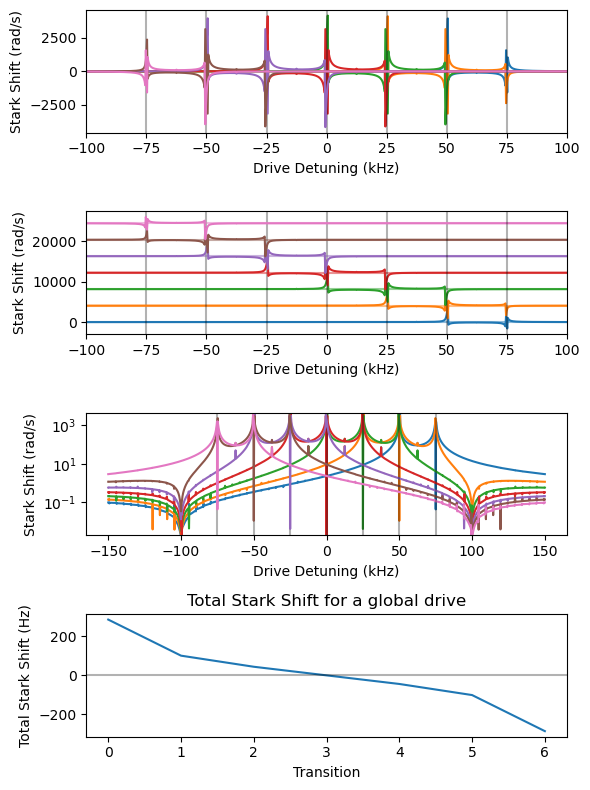

In [229]:
tot_stark_shift = plot_stark_shift(freq_array, ss_array, splitting=splitting)

In [232]:
np.array(tot_stark_shift)/2/np.pi

array([ 2.85636890e+02,  1.00870656e+02,  4.40736152e+01, -1.08594739e-12,
       -4.40736152e+01, -1.00870656e+02, -2.85636890e+02])